In [1]:
import sys
sys.path.append('..')
from src.scBriDi import scBriDi
import numpy as np
import torch
import scanpy as sc

d:\App\Anaconda\Lib\site-packages\scanpy\_utils\__init__.py:35: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
d:\App\Anaconda\Lib\site-packages\scanpy\__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
d:\App\Anaconda\Lib\site-packages\scanpy\readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


# scBriDi: Spatial Coordinate Assignment


To bridge dissociated single-cell data with spatial modalities, a similarity matrix between spatial transcriptomics (ST) and scRNA-seq is used to construct paired training datasets for alignment. After training in the aligned latent space, spatial coordinates are assigned to scRNA-seq cells through a similarity-driven matching and adaptive refinement algorithm — a globally optimal matching with adaptive coordinate assignment.

The processed `.h5ad` files can be downloaded from [Google Drive](https://drive.google.com/drive/folders/1TBBCRilA1VtL0pWdOGgyv44uf6ojWsuv?usp=drive_link).

In [ ]:
rna_data = sc.read_h5ad('../data/mouse_brain/rna_processed_3k.h5ad')
spatial_data = sc.read_h5ad('../data/mouse_brain/st_processed_3k.h5ad')

In [3]:

from src.config import cfg
device = 'cuda' if torch.cuda.is_available() else 'cpu'

## Spatial Alignment Training

The scRNA-seq and spatial transcriptomics data are jointly embedded into the aligned latent space using the scBriDi framework. A similarity-driven paired training set is constructed to bridge the two modalities, with cluster-based matching for unpaired training.

In [4]:
step = ["rna","spatial"]
cfg_rna_sp = {xtype: cfg[xtype] for xtype in step}
scbridi_rna_sp = scBriDi(device=device, cfg=cfg_rna_sp, xtypes=step,n_clusters=8,save_path='../param/mouseSP').to(device)
scbridi_rna_sp.svd({"rna":rna_data,"spatial":spatial_data})

In [5]:
scbridi_rna_sp.lr = 6e-5
scbridi_rna_sp.phases = {
                'pretrain': {'contrast': 0.0, "intra":0.0,"dec":0},
                'warmup': {'contrast': 0.03, "intra": 0.3, "dec": 0.05},
                'full': {'contrast': 0.1, "intra": 1,"dec": 0.7}}
scbridi_rna_sp.train_model(n_epoch=1400,unpaired=True,match_method="cluster_based")

From sup_info read 'rna' labels, total 8 types


d:\App\Anaconda\Lib\site-packages\scanpy\neighbors\__init__.py:427: FutureWarning: Use obsm (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`) instead of AnnData.obsm_keys, AnnData.obsm_keys is deprecated and will be removed in the future.
  if "X_diffmap" in adata.obsm_keys():
d:\App\Anaconda\Lib\site-packages\scanpy\tools\_utils.py:40: UserWarning: You’re trying to run this on 128 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  warnings.warn(
d:\App\Anaconda\Lib\site-packages\scanpy\preprocessing\_pca\__init__.py:245: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  Version(ad.__version__) < Version("0.9")
d:\Lab\code\scBriDi\tutorial\..\src\util.py:76: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  direct

spatial clustering done, total 6 clusters
Use cluster-based matching
Created 2514 pairs


100%|██████████| 1400/1400 [38:39<00:00,  1.66s/it, Phase: full | Loss: 0.8562 | contrastLoss: 0.4419 | intraLoss: 0.0064 | DECLoss: 0.3142 | rna: 0.0195 | spatial: 0.0205 | contrastWeight: 0.100 | intraWeight: 1.000 | decWeight: 0.700]   


In [6]:
soutput = scbridi_rna_sp.inference(out_types=["spatial"],condition_data={"spatial":spatial_data},only_decode=False)["spatial"]

d:\Lab\code\scBriDi\tutorial\..\src\sampler.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  gt = torch.tensor(gt).to(device)


['spatial'] pretrained


time: 0: 100%|██████████| 1000/1000 [00:46<00:00, 21.71it/s] 


In [7]:
routput = scbridi_rna_sp.inference(out_types=["spatial"],condition_data={"spatial":rna_data},only_decode=False)["spatial"]

['spatial'] pretrained


d:\Lab\code\scBriDi\tutorial\..\src\sampler.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  gt = torch.tensor(gt).to(device)
time: 0: 100%|██████████| 1000/1000 [05:48<00:00,  2.87it/s] 


In [8]:
import pandas as pd
import seaborn as sns
def simple_scatter(anndata, 
                   use_rep='spatial', 
                   color_col='cell_type', 
                   size=20, 
                   marker='o', 
                   x_label='x', 
                   y_label='y', 
                   palette='Set1', 
                   show=True, 
                   set_equal=False, 
                   title=None, 
                   linewidth=0, 
                   figsize=(4.5, 4), 
                   save_path=None):
    import  pandas as pd

    pos_df = pd.DataFrame(anndata.obs, columns=['x', 'y'])
    pos_df.index = anndata.obs.index.tolist()

    plot_df = pd.concat([anndata.obs[[color_col]], pos_df], axis=1)

    plot_scatter(plot_df,
                 x_col='x',
                 y_col='y',
                 color_col=color_col,
                 size=size,
                 marker=marker,
                 x_label=x_label,
                 y_label=y_label,
                 palette=palette,
                 show=show,
                 set_equal=set_equal,
                 title=title,
                 linewidth=linewidth,
                 figsize=figsize,
                 save_path=save_path)
def plot_scatter(df, x_col, y_col, color_col, ax=None, 
                 palette=None, x_label=None, y_label=None, show_ticks=True, title=None, size=None, marker='o', 
                 rotation_angle=0, reverse_y=False ,reverse_x=False,
                 hue_order=None,show=True,linewidth=0,set_equal=True,figsize=(5,4),save_path=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize, facecolor='white')  
        ax.set_facecolor('white') 
    else:
        ax.set_facecolor('white') 
        ax.figure.set_facecolor('white')  
        ax.figure.set_size_inches(figsize)
    if reverse_y:
        df['y_rot'] = -df['y_rot']
    if reverse_x:
        df['x_rot'] = -df['x_rot']
        
    if ax is None:
        ax = plt.gca()
    ax.figure.set_size_inches(figsize)
    sns.scatterplot(data=df, 
                    x='x', 
                    y='y', 
                    hue=color_col, 
                    palette=palette, 
                    s=size, 
                    marker=marker, 
                    legend='full', 
                    hue_order=hue_order, 
                    ax=ax, 
                    linewidth=linewidth)
    
    if title:
        ax.set_title(title)
    else:
        ax.set_title(f'Scatter plot of {y_col} vs {x_col}')
    
    ax.set_xlabel(x_label if x_label else x_col)
    ax.set_ylabel(y_label if y_label else y_col)
    
    if not show_ticks:
        ax.set_xticks([])
        ax.set_yticks([])
    
        ax.legend(title=color_col, bbox_to_anchor=(1.05, 1), loc='upper left',
                      frameon=True,          
                      facecolor='none',      
                      edgecolor='black',     
                      framealpha=0,
                    markerscale=2)           
    if set_equal:
        ax.axis('equal')
    if save_path:
        plt.savefig(save_path, bbox_inches='tight') 
        print(f"Plot saved to {save_path}")
    if show:
        plt.show()
def sdplot(anndata,
           use_rep='spatial',
           color_col='cell_type',
           size=20,
           marker='o',
           rotation_angle=-90,
           show_ticks=False,
           x_label='Spatial_x',
           y_label='Spatial_y',
           palette='Set1',
           show=False,
           set_equal=False,
           highlight=None,
           title=None,
           highlight_color=['#D8281A','#CDCECA'],
           ax=None,
           linewidth=0,
           ncols=5,
           figsize=(4.5,4),
           save_path=None):
  
    pos_df = pd.DataFrame(anndata.obs, columns=['x', 'y'])
    pos_df.index = anndata.obs.index.tolist()
    plot_df = pd.concat([anndata.obs[[color_col]], pos_df], axis=1)
    
    if highlight is not None:
        palette_colors = {'Selected cells': highlight_color[0],'Other': '#CDCECA'}
        
        if isinstance(highlight, str):
            highlight = [highlight]

        if len(highlight)<ncols:
            ncols = len(highlight)
        n_features = len(highlight) 
        nrows = -(-n_features // ncols) 
        fig, axes = plt.subplots(nrows=nrows, ncols=ncols, 
                                figsize=(figsize[0] * ncols, figsize[1] * nrows),
                                facecolor='white')  

        if n_features > 1:
            axes = axes.flatten()

        for idx, feature in enumerate(highlight):
            ax = axes[idx] if n_features > 1 else axes

            plot_df['highlight'] = plot_df[color_col].apply(lambda x: 'Other' if x != feature else 'Selected cells')

            plot_scatter(plot_df,
                         x_col='x',
                         y_col='y',
                         color_col='highlight',
                         size=size,
                         marker=marker,
                         rotation_angle=rotation_angle,
                         show_ticks=show_ticks,
                         x_label=x_label,
                         y_label=y_label,
                         palette=palette_colors,
                         show=False,
                         set_equal=set_equal,
                         title=feature,
                        ax=ax,
                        linewidth=linewidth,
                        figsize=figsize)
        plt.tight_layout()
        for idx in range(n_features, nrows*ncols):
            fig.delaxes(axes.flatten()[idx])

        if save_path:
            plt.savefig(save_path, bbox_inches='tight') 
            print(f"Plot saved to {save_path}")
        if show:
            plt.show()
        else:
            plt.close()


    else:
        plot_scatter(plot_df,
                     x_col='x',
                     y_col='y',
                     color_col=color_col,
                     size=size,
                     marker=marker,
                     rotation_angle=rotation_angle,
                     show_ticks=show_ticks,
                     x_label=x_label,
                     y_label=y_label,
                     palette=palette,
                     show=show,
                     set_equal=set_equal,
                     title=title,
                     ax=ax,
                     figsize=figsize,
                     linewidth=linewidth,save_path=save_path)


In [9]:
sdplot(spatial_data,color_col='seurat_clusters',size=10,rotation_angle=0)


NameError: name 'plt' is not defined

## Adaptive Coordinate Assignment

After alignment, spatial coordinates are assigned to scRNA-seq cells through a globally optimal matching algorithm with adaptive coordinate refinement. The `map_rna_to_spatial` function computes expression similarity between RNA and spatial cells, then uses a deferred acceptance algorithm to optimally allocate cells to spatial spots with biologically-informed quotas, producing a spatially-resolved single-cell map.

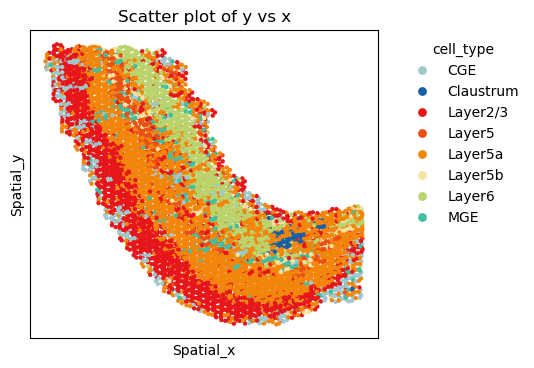

In [ ]:
from src.util import map_rna_to_spatial
import matplotlib.pyplot as plt
routput.var= rna_data.var
rna_mapped = map_rna_to_spatial(
    routput, soutput,
    similarity_method='hybrid',
    avoid_overlap=True,
    neighbor_weight=0.4
)
rna_col = {
    "Layer2/3": "#E6161B",
    "Layer5": "#EC4E14",
    "Layer5a": "#F2860D",
    "Layer5b": "#f8e1a0",
    "Layer6": "#BAD36C",
    "CGE": "#9EC7CE",
    'MGE':"#40C0A1",
    "Claustrum": "#195FA5"
}
sdplot(rna_mapped,color_col='cell_type',size=10,rotation_angle=0,palette=rna_col)